# Seaborn - Intro

## Notes

[Seaborn Gallery](https://seaborn.pydata.org/examples/index.html)

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. Here's why you might use Seaborn over matplotlib:

* Simplified Syntax: Less code for complex visualizations.
* Built-in Themes: Predefined styles for attractive plots.
* Better Color Handling: Advanced palette options and usage.
* Statistical Plotting: Supports advanced plots like violin and box plots.
* Data Frames Support: Direct plotting from pandas data structures.
* Automatic Estimation: Built-in linear regression plotting.
* Faceting: Easy creation of multi-plot grids for data comparison.

## Example

### Original Code

Let's use our visualization we made in the last exercise. First we'll load in the data as usual. The rest of the code is the same exact code as before.

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\KAIF FIROZ\anaconda3\envs\kaifs_python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Import Seaborn

In [3]:
import seaborn as sns

In [4]:
# Only get data analyst jobs in India.
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Drop NaN values from the column for plotting 
df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

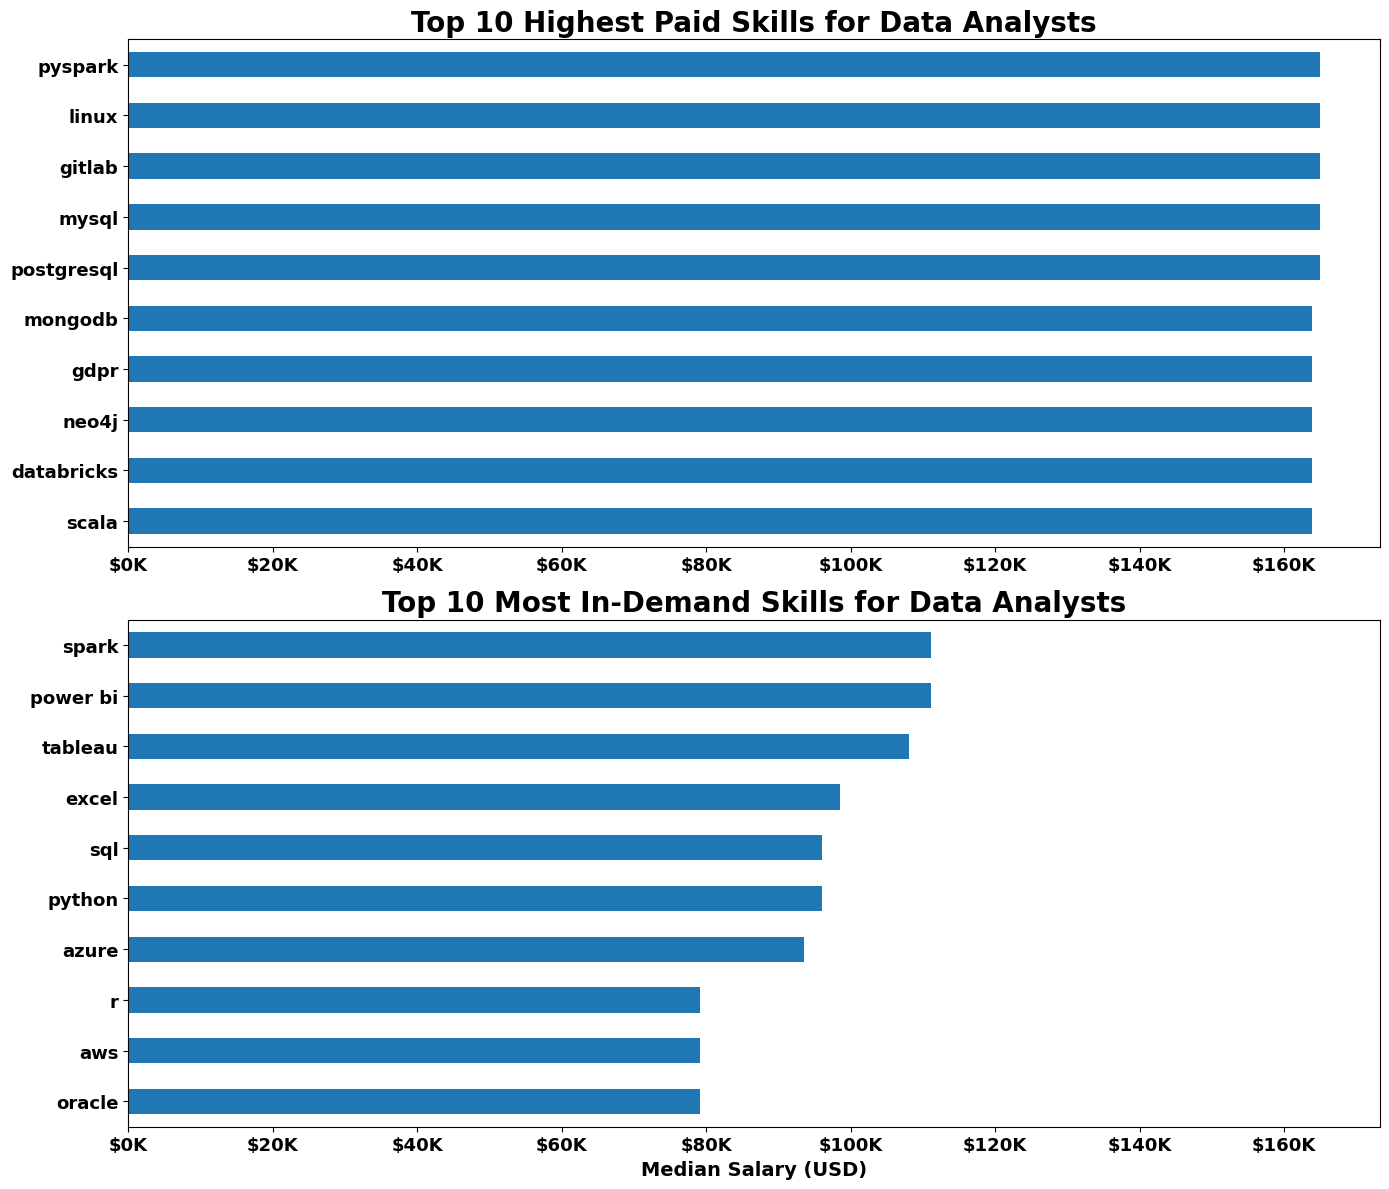

In [7]:
df_DA_IND = df_DA_IND.explode('job_skills')
df_DA_IND[['salary_year_avg','job_skills']]

df_DA_IND_ggrouped = df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_IND_top_pay = df_DA_IND_ggrouped.sort_values(by='median', ascending= False).head(10)

df_DA_IND_skills = df_DA_IND_ggrouped.sort_values(by='count', ascending= False).head(10).sort_values(by='median', ascending= False).head(10)


fig, ax = plt.subplots(2, 1, figsize=(14, 12))

df_DA_IND_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts',fontsize= 20, fontweight='bold')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


df_DA_IND_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts',fontsize= 20, fontweight='bold')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


ax[1].set_xlim(ax[0].get_xlim())

for i in [0, 1]:
    # X and Y tick size
    ax[i].tick_params(axis='x', labelsize=13)
    ax[i].tick_params(axis='y', labelsize=13)

    # Make tick labels bold
    for label in ax[i].get_xticklabels() + ax[i].get_yticklabels():
        label.set_fontweight('bold')

    # If you use axis labels later
    ax[i].xaxis.label.set_size(14)
    ax[i].yaxis.label.set_size(14)
    ax[i].xaxis.label.set_fontweight('bold')
    ax[i].yaxis.label.set_fontweight('bold')


fig.tight_layout()

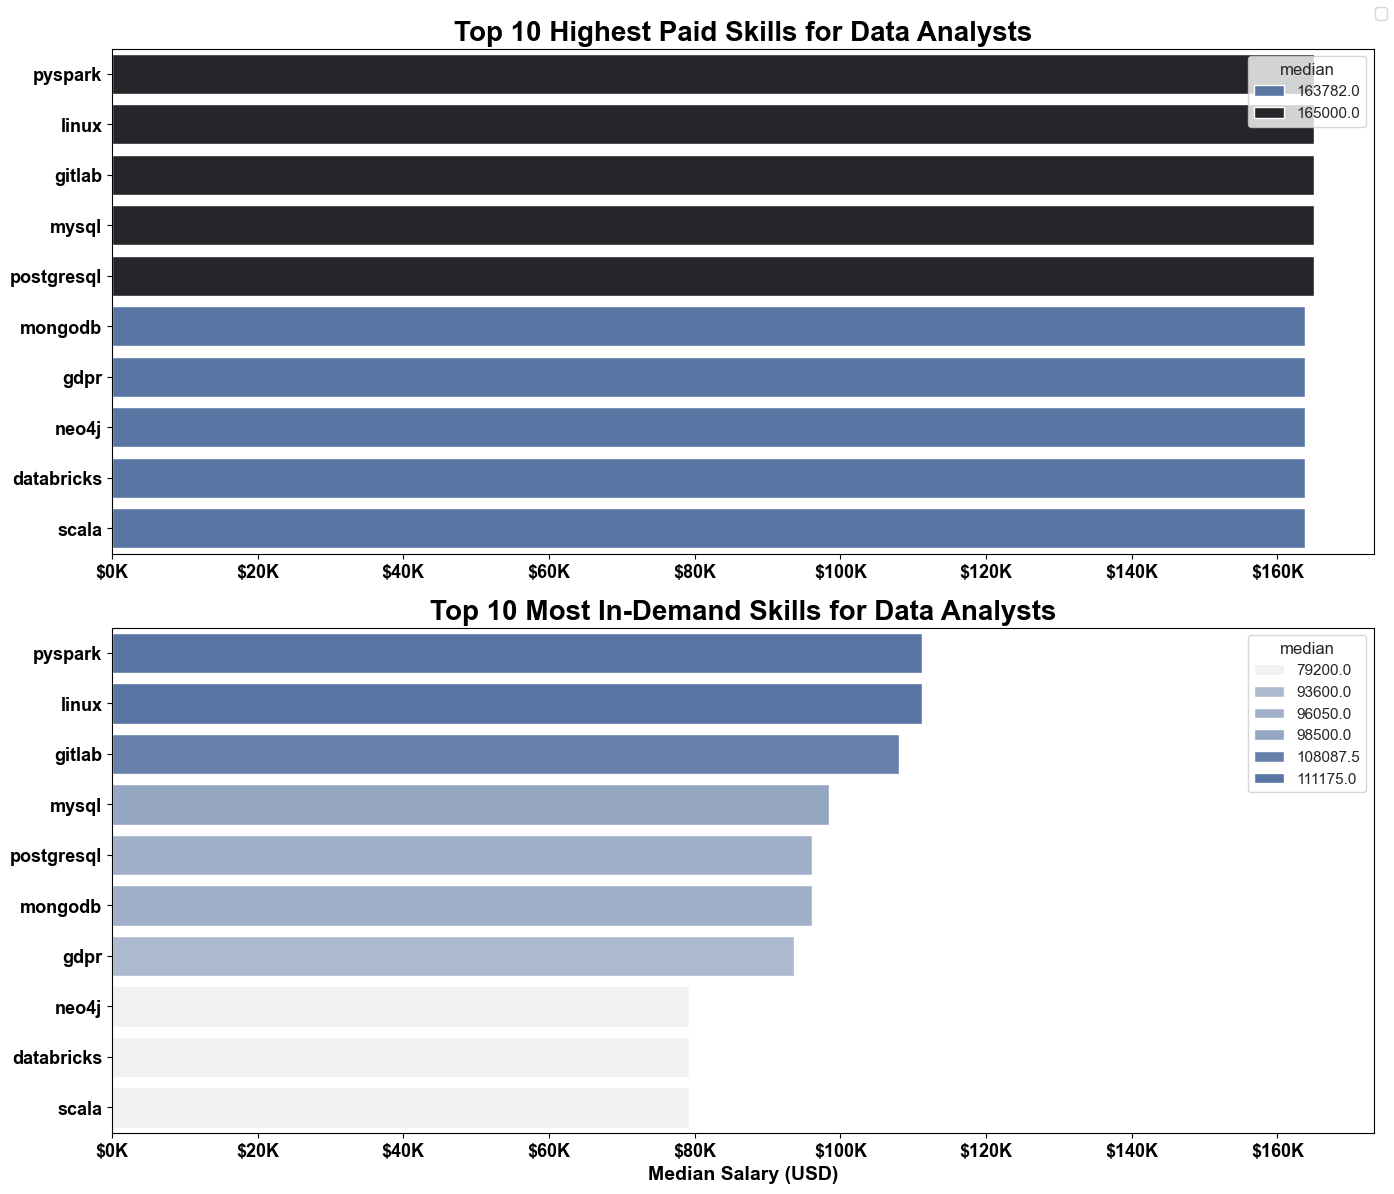

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(14, 12))

sns.set_theme(style='ticks')

sns.barplot(data=df_DA_IND_top_pay, x='median', y= df_DA_IND_top_pay.index, ax=ax[0], hue= 'median', palette='dark:b_r')

# df_DA_IND_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts',fontsize= 20, fontweight='bold')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_IND_skills, x='median', y= df_DA_IND_top_pay.index, ax=ax[1], hue= 'median', palette='light:b')

# df_DA_IND_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts',fontsize= 20, fontweight='bold')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


ax[1].set_xlim(ax[0].get_xlim())

for i in [0, 1]:
    # X and Y tick size
    ax[i].tick_params(axis='x', labelsize=13)
    ax[i].tick_params(axis='y', labelsize=13)

    # Make tick labels bold
    for label in ax[i].get_xticklabels() + ax[i].get_yticklabels():
        label.set_fontweight('bold')

    # If you use axis labels later
    ax[i].xaxis.label.set_size(14)
    ax[i].yaxis.label.set_size(14)
    ax[i].xaxis.label.set_fontweight('bold')
    ax[i].yaxis.label.set_fontweight('bold')


fig.tight_layout()
fig.legend('')

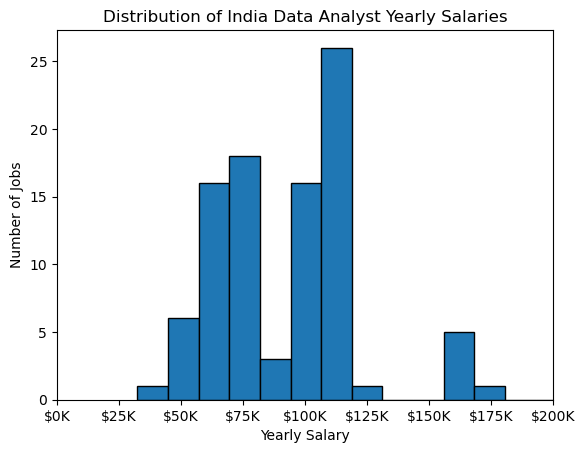

In [5]:
df_DA_IND['salary_year_avg'].plot(kind= 'hist', bins  = 50, edgecolor= 'black')
plt.xlim(0, 200000)

ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))


plt.title('Distribution of India Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()


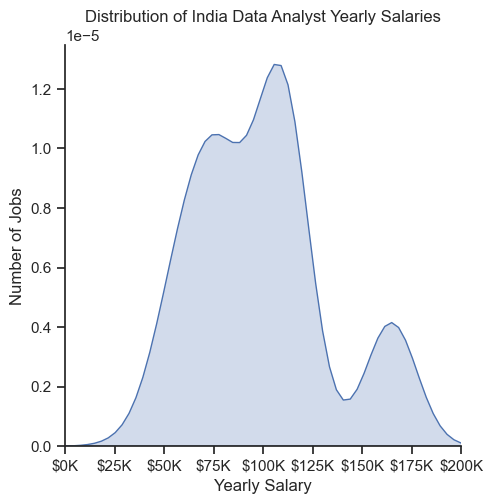

In [20]:
sns.displot(df_DA_IND['salary_year_avg'],kind= 'kde', fill= True)


ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 200000)

plt.title('Distribution of India Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()


In [31]:
df_ind = df[df['job_country'] == 'India'].sort_values(by='salary_year_avg',ascending= False)


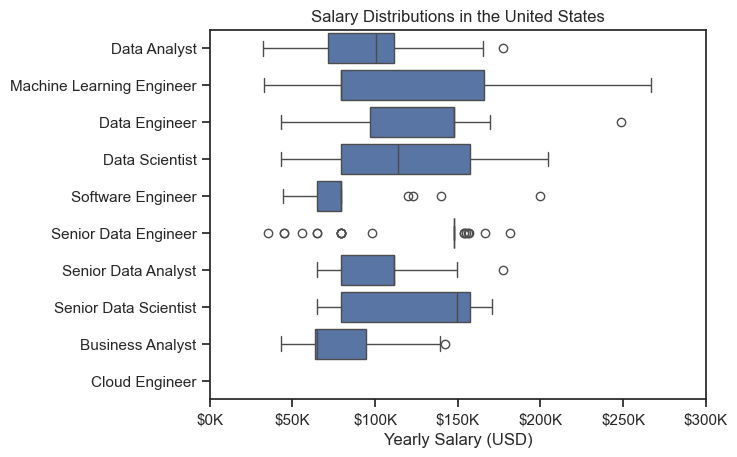

In [34]:
sns.boxplot(data=df_ind, x='salary_year_avg', y='job_title_short')
sns.set_theme(style='ticks')

# this is all the same
plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0, 300000)
plt.show()